# Sistema di Face Detection per una fotocamera digitale

L’obiettivo di questo progetto è costruire un sistema di Face Detection sviluppato interamente con Scikit-learn, senza ricorrere a modelli pre-addestrati o librerie di deep learning.
La pipeline deve essere in grado di prendere in ingresso un’immagine e restituire una lista di coordinate (bounding box) che individuano le regioni contenenti i volti. In caso non siano presenti volti, il sistema dovrà restituire una lista vuota.

Il progetto dovrà inoltre rispettare vincoli di limitata capacità computazionale, quindi l’intero sistema dovrà essere sviluppato privilegiando approcci leggeri basati su metodi classici di Machine Learning.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import requests
from io import BytesIO
import joblib

from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import hog

from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.datasets import fetch_olivetti_faces, fetch_openml
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report

## Creation of the dataset

Per la costruzione del dataset completo abbiamo bisogno di **due insiemi di immagini**: uno contenente **primi piani di volti umani** e uno costituito da **immagini prive di volti**.
Gli **esempi positivi** vengono ricavati dal dataset *Olivetti Faces*, che include esclusivamente volti frontali.
Per gli **esempi negativi** selezioniamo invece **400 immagini** dal dataset *CIFAR-10*, selezionando esclusivamente classi che non contengono volti umani, per mantenere un bilanciamento tra le due classi.


In [2]:
# Loading Olivetti Faces dataset
olivetti_df = fetch_olivetti_faces()
faces = olivetti_df.images

print(f"Shape of Olivetti dataset: {faces.shape}")
print(f"Image size: {faces.shape[1:]}")
print(f"Pixel value range: min={faces.min():.3f}, max={faces.max():.3f}")

Shape of Olivetti dataset: (400, 64, 64)
Image size: (64, 64)
Pixel value range: min=0.000, max=1.000


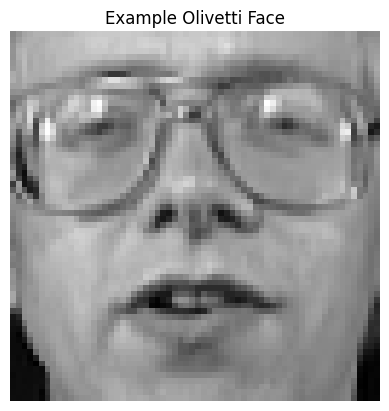

In [3]:
plt.imshow(faces[10], cmap="gray")
plt.title("Example Olivetti Face")
plt.axis("off")
plt.show()

In [4]:
# Loading CIFAR_10 dataset
cifar_df = fetch_openml("CIFAR_10", version=1, as_frame=False)
images = cifar_df.data.reshape(-1, 3, 32, 32).transpose(0,2,3,1)
labels = cifar_df.target.astype(int)

selected_classes = [0, 1, 2, 4, 5, 6, 8, 9] # airplane, automobile, bird, deer, dog, frog, ship, truck
mask = np.isin(labels, selected_classes)
negatives = images[mask] / 255.0

print(f"Shape of CIFAR_10 dataset: {negatives.shape}")
not_faces = np.array([
    rgb2gray(resize(img, (64, 64))) for img in negatives[:400]
])

print(f"\nShape of CIFAR_10 dataset after scaling: {not_faces.shape}")
print(f"Image size: {not_faces.shape[1:]}")
print(f"Pixel value range: min={not_faces.min():.2f}, max={not_faces.max():.3f}")

Shape of CIFAR_10 dataset: (48000, 32, 32, 3)

Shape of CIFAR_10 dataset after scaling: (400, 64, 64)
Image size: (64, 64)
Pixel value range: min=0.00, max=1.000


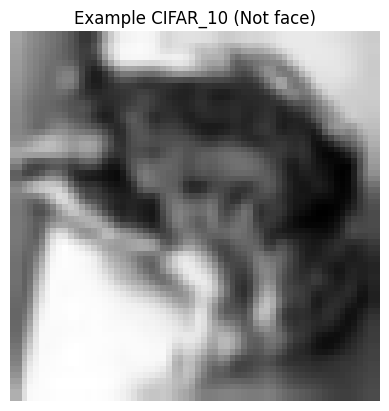

In [5]:
plt.imshow(not_faces[10], cmap="gray")
plt.title("Example CIFAR_10 (Not face)")
plt.axis("off")
plt.show()

Abbiamo ottenuto due insiemi di dati: **faces** e **not_faces**, ciascuno composto da **400 array NumPy** di dimensione **64×64**. I valori dei pixel sono compresi tra **0 e 1**, il che indica che le immagini risultano **normalizzate**.


Creiamo ora le etichette per i nostri esempi, in modo da renderli riconoscibili ad un classificatore come **positivi (faces)** o **negativi (not_faces)**.


In [6]:
# Creation of labels
faces_labels = np.ones(len(faces))
not_faces_labels = np.zeros(len(not_faces))

## Feature Extraction

Per *Feature Extraction* si intende il processo attraverso il quale si individuano e si estraggono le informazioni più significative da dati grezzi (ad esempio un’immagine composta da pixel), riducendone la dimensionalità senza perdere dettagli rilevanti. In questo modo si ottengono dati più compatti e interpretabili dagli algoritmi di Machine Learning.

In questo progetto utilizzeremo la tecnica **Histogram of Oriented Gradients (HOG)**.
Questo metodo prevede di suddividere l’immagine in piccole celle e di calcolare, per ciascuna di esse, l’istogramma delle direzioni dei gradienti dei pixel.
Per rendere il descrittore più robusto a variazioni di luminosità e contrasto, gli istogrammi vengono poi normalizzati.


In [7]:
def extract_hog_features(images):
    """
    Extracts HOG features from one or more grayscale images.
    """
    hog_params = {
        "pixels_per_cell": (6, 6),
        "cells_per_block": (3, 3),
        "orientations": 11,
        "block_norm": "L2-Hys"
    }

    features = [hog(img, **hog_params) for img in images]
    return np.array(features)

In [8]:
def plot_image_and_hog(image):
    """
    Plot an image and its HOG representation.
    """
    hog_params = {
        "pixels_per_cell": (6, 6),
        "cells_per_block": (3, 3),
        "orientations": 11,
        "block_norm": "L2-Hys"
    }

    features, hog_image = hog(image, visualize=True, **hog_params)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(hog_image, cmap="gray")
    plt.title("HOG Descriptor")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Per comprendere più a fondo quali informazioni vengono effettivamente estratte da un’immagine durante la fase di feature extraction, osserviamo un confronto visivo tra l’immagine originale e la sua rappresentazione tramite descrittori HOG.

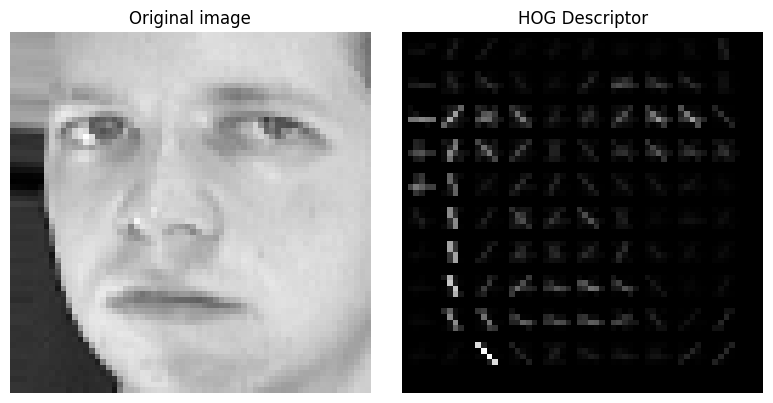

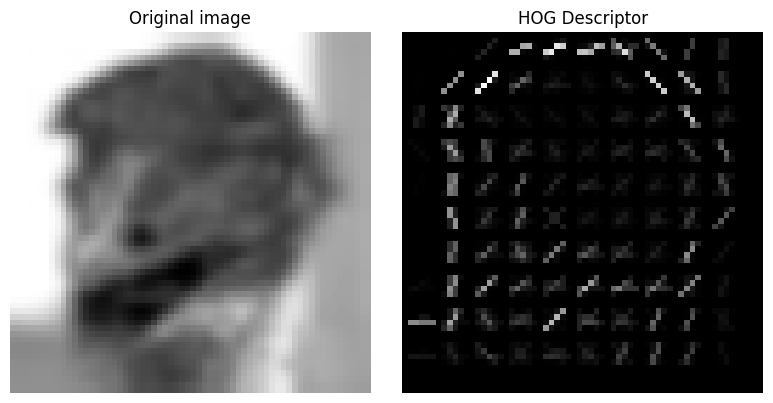

In [9]:
plot_image_and_hog(faces[5])
plot_image_and_hog(not_faces[5])

Con queste rappresentazioni riusciamo a capire in che modo l’algoritmo “vede” l’immagine e quali caratteristiche utilizza per riconoscere e distinguere i volti da altre tipologie di oggetti.

## Pipeline

Una delle tecniche più efficaci per affrontare questo tipo di problema di computer vision è rappresentata dalle **Support Vector Machines (SVM)**.
Le SVM sono modelli di classificazione che cercano di separare le diverse classi di dati, in questo caso *faces* e *not_faces*, trovando il confine ottimale tra di esse.
Grazie alla loro capacità di gestire anche relazioni non lineari tramite funzioni kernel, offrono buone prestazioni con un modello leggero ed efficiente, adatto a contesti con risorse di calcolo limitate.

La nostra **pipeline** sarà quindi composta da:

1. Estrazione delle feature HOG
2. Classificazione tramite SVM (SVC)


In [10]:
# Pipeline creation
face_pipeline = Pipeline([
    ('hog', FunctionTransformer(extract_hog_features)),
    ('svc', SVC(probability=True))
])

In [11]:
# Pre-Processing
X = np.concatenate((faces, not_faces), axis=0)
y = np.concatenate((faces_labels, not_faces_labels), axis=0)
print(f"Shape X: {X.shape}\nShape y: {y.shape}")

Shape X: (800, 64, 64)
Shape y: (800,)


In [12]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=16, stratify=y
)

Procediamo con il tuning degli iperparametri utilizzando la tecnica della **Randomized Search** con Cross Validation.
Questo approccio consente di esplorare in modo casuale diverse combinazioni di parametri all’interno di intervalli predefiniti e di valutarne le prestazioni tramite la validazione incrociata, individuando così la configurazione che offre i migliori risultati senza dover testare tutte le possibili combinazioni.

In [13]:
param_range = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

param_grid = [
    {'svc__C': param_range, 'svc__kernel': ['linear']},
    {'svc__C': param_range, 'svc__gamma': param_range, 'svc__degree': [2,3,4,5], 'svc__kernel': ['poly']},
    {'svc__C': param_range, 'svc__gamma': param_range, 'svc__kernel': ['rbf']}
]

In [14]:
# Randomized Search
rs = RandomizedSearchCV(
    estimator=face_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=16,
)

In [15]:
# Addestramento
rs.fit(X_train, y_train)
print("Best params found: ")
print(rs.best_params_)

Best params found: 
{'svc__kernel': 'poly', 'svc__gamma': 10.0, 'svc__degree': 4, 'svc__C': 0.0001}


Il modello di SVC ottimizzato risulta avere un kernel polinomiale di grado 4, con un valore del parametro γ = 10 e del parametro C = 0.0001.

In [16]:
face_classifier = rs.best_estimator_

In [17]:
# Model evaluation
y_pred = face_classifier.predict(X_test)
print("Classification report: ")
print(classification_report(y_test, y_pred, target_names=["Not-Faces", "Faces"]))

Classification report: 
              precision    recall  f1-score   support

   Not-Faces       1.00      1.00      1.00       120
       Faces       1.00      1.00      1.00       120

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



Il classification report mostra prestazioni perfette del modello: precision, recall e f1-score pari a 1.00 per entrambe le classi (Faces e Not-Faces).
Anche l’accuracy è del 100%, segnalando che il classificatore ha riconosciuto correttamente tutti gli esempi del set di test.
Questi risultati indicano che il modello ha appreso in modo estremamente efficace a distinguere tra volti e non-volti, anche se sarà importante verificare che non si tratti di overfitting.

In [18]:
# Save model
joblib.dump(face_classifier, "face_classification_model.joblib")

['face_classification_model.joblib']

In [19]:
# Load model
fd_pipe=joblib.load("face_classification_model.joblib")
print("Pipeline loaded successfully!")

Pipeline loaded successfully!


## Face Detection

### Functions

Realizziamo ora un **sistema di Face Detection** capace di identificare automaticamente la presenza di un volto umano all’interno di un’immagine.
L’idea alla base consiste nel far “scorrere” un riquadro di analisi su tutta l’immagine: per ogni porzione esaminata, il classificatore addestrato viene applicato per determinare se contiene o meno un volto. In questo modo il sistema risulta indipendente sia dalla **posizione** del volto, sia dalle **dimensioni** dell’immagine di input.

Per ottenere questo risultato si combinano due tecniche complementari. La **Image Pyramid** genera versioni dell’immagine a diverse scale, consentendo di rilevare volti di varie dimensioni, mentre la **Sliding Window** permette di scandire l’intera immagine passo dopo passo.
Infine, per evitare che più riquadri sovrapposti segnalino lo stesso volto, viene utilizzato un algoritmo di **Non-Maximum Suppression**, che mantiene solo il riquadro con la probabilità più alta di contenere un volto, eliminando le duplicazioni.

In [20]:
def image_pyramid(image, scale=1.2, min_size=(30,30)):
    '''
    Generates a pyramid of progressively resized images.
    '''
    # First level: original image
    yield image

    while True:
        # Calculate the new reduced width/height
        new_width = int(image.shape[1] / scale)
        new_height = int(image.shape[0] / scale)

        # Resize while maintaining the aspect ratio
        image = cv2.resize(image, (new_width, new_height), interpolation=cv2.INTER_AREA)

        # If the image is smaller than the minimum size, break
        if image.shape[0] < min_size[1] or image.shape[1] < min_size[0]:
            break

        # Returns the current level of the pyramid
        yield image

In [21]:
def sliding_window(image, step_size, window_size):
    '''
    A generator that scrolls a window over an image, progressively returning each region of interest.
    '''
    win_w, win_h = window_size

    # Scroll the window along the image
    for y in range(0, image.shape[0], step_size):
        for x in range(0, image.shape[1], step_size):
            # Extracts the current window
            window = image[y:y + win_h, x:x + win_w]

            # Returns coordinates and window
            yield (x, y, window)

In [22]:
def non_maximum_suppression(boxes, scores, iou_threshold=0.3):
    """
    Apply Non-Maximum Suppression (NMS) to remove redundant bounding boxes.
    """
    if len(boxes) == 0:
        return np.array([])

    boxes = np.array(boxes)
    scores = np.array(scores)

    # Coordinates of the angles (x1, y1, x2, y2)
    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 0] + boxes[:, 2]
    y2 = boxes[:, 1] + boxes[:, 3]

    # Calculate the area of ​​each bounding box
    areas = (x2 - x1 + 1) * (y2 - y1 + 1)

    # Sort the score indices in descending order
    order = np.argsort(scores)[::-1]

    keep = []

    while order.size > 0:
        i = order[0]
        keep.append(i)

        # Calculates the coordinates of the intersection between the current box and the others
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        # Width and height of the intersection
        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)

        # Intersection area
        inter = w * h

        # IoU (Intersection over Union) calculation
        iou = inter / (areas[i] + areas[order[1:]] - inter)

        # Keep only boxes with IoU less than the threshold
        remaining = np.where(iou <= iou_threshold)[0]
        order = order[remaining + 1]

    return boxes[keep].astype(int)

In [23]:
def detect_faces(image, face_pipeline, step_size=8, window_size=(64, 64), pyramid_scale=1.2, min_size=(30, 30), use_nms=False,
    iou_threshold=0.3):
    """
    Detect faces in an image using an image pyramid and a sliding window.
    If use_nms=True, applies Non-Maximum Suppression (NMS) to reduce duplicates.
    """
    # Image format normalization
    if image.ndim == 3:
        if image.shape[-1] == 4:
            image = cv2.cvtColor(image, cv2.COLOR_RGBA2RGB)
        elif image.shape[-1] == 3:
            pass
    elif image.ndim == 2:
        pass
    else:
        raise ValueError("Image format not supported.")

    bounding_boxes = []
    scores = []

    # Scroll through the levels of the pyramid
    for resized in image_pyramid(image, scale=pyramid_scale, min_size=min_size):
        scale_factor = image.shape[0] / float(resized.shape[0])

        # Scroll the floating window to the current level
        for (x, y, window) in sliding_window(resized, step_size=step_size, window_size=window_size):

            # Skip partial windows
            if window.shape[0] != window_size[1] or window.shape[1] != window_size[0]:
                continue

            gray_window = rgb2gray(window, channel_axis=-1) if window.ndim == 3 else window

            # HOG feature extraction and prediction
            hog_features = face_pipeline.named_steps["hog"].transform([gray_window])
            classifier = face_pipeline.named_steps["svc"]

            score = classifier.decision_function(hog_features.reshape(1, -1))[0]

            # If it's a face, add the bounding box
            if score > 0:
                x_start = int(x * scale_factor)
                y_start = int(y * scale_factor)
                w = int(window_size[0] * scale_factor)
                h = int(window_size[1] * scale_factor)

                bounding_boxes.append((x_start, y_start, w, h))
                scores.append(score)

    # Application of Non-Maximum Suppression
    if use_nms:
        return non_maximum_suppression(bounding_boxes, scores, iou_threshold=iou_threshold)

    return bounding_boxes

In [24]:
def draw_bounding_boxes(image, bounding_boxes, color=(0, 255, 0), thickness=2):
    """
    Draw bounding boxes on an image.
    """
    # Create a copy to avoid changing the original image
    image_with_boxes = image.copy()

    # Draw all bounding boxes
    for (x, y, w, h) in bounding_boxes:
        cv2.rectangle(image_with_boxes, (x, y), (x + w, y + h), color, thickness)

    return image_with_boxes

In [25]:
def test_and_plot(image_url, fd_pipe, use_nms=False):
    """
    Downloads an image from the URL, applies face detection and displays the result.
    """
    response = requests.get(image_url)
    test_image = mpimg.imread(BytesIO(response.content), format='jpg')

    boxes = detect_faces(test_image, fd_pipe, use_nms=use_nms)
    print(f"Detected {len(boxes)} box: {boxes}")

    plt.imshow(draw_bounding_boxes(test_image, boxes))
    plt.axis("off")
    plt.show()

### Test

In [26]:
# URL of my public repository on GitHub
BASE_URL = "https://github.com/NicoloDiscotto/face_detection_samples/raw/main/"

Detected 9 box: [(124, 152, 110, 110), (116, 133, 133, 133), (116, 150, 133, 133), (133, 150, 133, 133), (100, 120, 160, 160), (120, 120, 160, 160), (100, 140, 160, 160), (120, 140, 160, 160), (96, 120, 192, 192)]


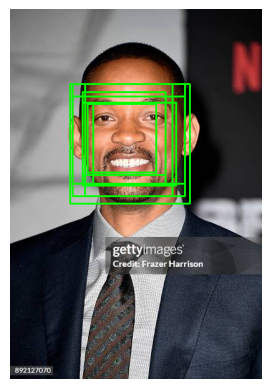

Detected 1 box: [[116 150 133 133]]


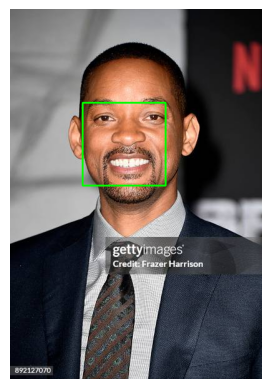

In [27]:
test_and_plot(BASE_URL+"smith.jpg", fd_pipe)
test_and_plot(BASE_URL+"smith.jpg", fd_pipe, use_nms=True)

Nel primo test, effettuato su un’immagine con un solo volto in primo piano, il sistema non ha generato falsi positivi ma ha individuato nove riquadri sovrapposti nella zona del volto.
Dopo l’applicazione della Non-Maximum Suppression (NMS), i riquadri ridondanti sono stati eliminati, lasciando un solo bounding box accurato posizionato correttamente sul volto.

Detected 7 box: [(136, 40, 64, 64), (144, 40, 64, 64), (384, 56, 64, 64), (384, 64, 64, 64), (256, 72, 64, 64), (256, 80, 64, 64), (250, 76, 76, 76)]


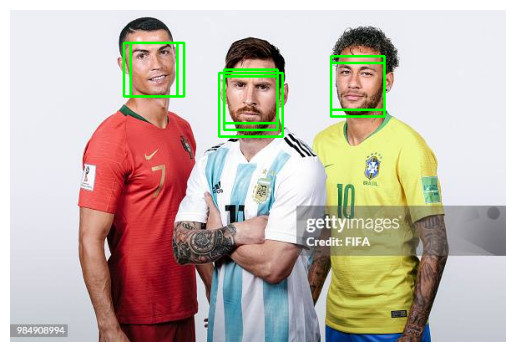

Detected 3 box: [[256  80  64  64]
 [384  56  64  64]
 [144  40  64  64]]


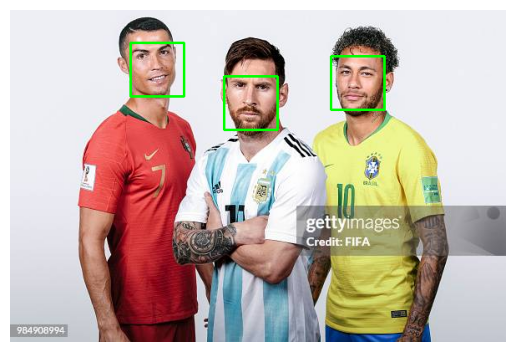

In [28]:
test_and_plot(BASE_URL+"football.jpg", fd_pipe)
test_and_plot(BASE_URL+"football.jpg", fd_pipe, use_nms=True)

Anche nel secondo test il sistema identifica correttamente tutti i volti, dimostrando una buona capacità di generalizzazione anche in presenza di più soggetti nella stessa scena.

Detected 10 box: [(344, 0, 64, 64), (344, 8, 64, 64), (200, 40, 64, 64), (440, 112, 64, 64), (440, 120, 64, 64), (200, 160, 64, 64), (192, 153, 76, 76), (185, 150, 92, 92), (300, 173, 92, 92), (292, 167, 111, 111)]


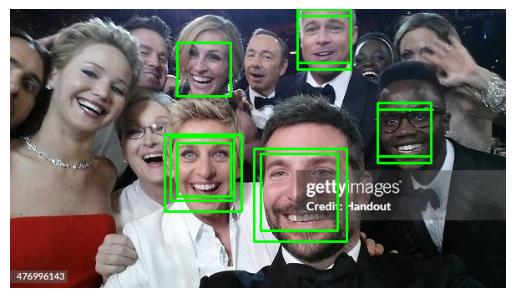

Detected 5 box: [[192 153  76  76]
 [344   8  64  64]
 [292 167 111 111]
 [440 120  64  64]
 [200  40  64  64]]


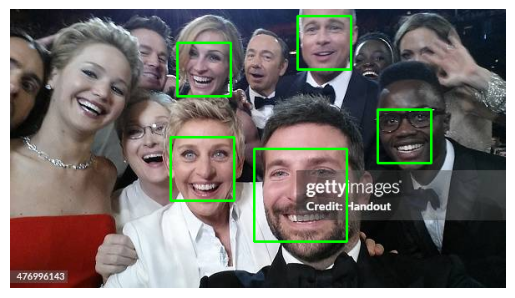

In [29]:
test_and_plot(BASE_URL+"oscar.jpg", fd_pipe)
test_and_plot(BASE_URL+"oscar.jpg", fd_pipe, use_nms=True)

Nel terzo test, eseguito su un’immagine di gruppo con dieci persone, il sistema è riuscito a rilevare solo 5 volti su 10.
Questo risultato può essere giustificato considerando che alcuni volti non sono in posizione frontale, a differenza di quelli utilizzati durante l’addestramento del modello. Inoltre, in alcune aree dell’immagine la luce è irregolare e parte dei volti risulta parzialmente in ombra, rendendo più difficile per il classificatore riconoscere le caratteristiche tipiche del volto.
Questi fattori mettono in evidenza i limiti del modello rispetto a pose, illuminazione e condizioni di visibilità diverse da quelle presenti nei dati di addestramento.

Detected 0 box: []


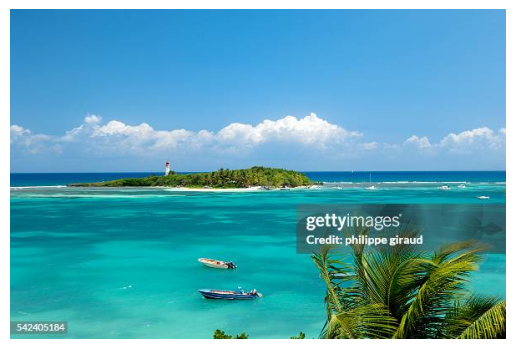

In [30]:
test_and_plot(BASE_URL+"beach.jpg", fd_pipe)

Infine, eseguiamo un ultimo test su un’immagine priva di volti, in cui il sistema non rileva alcun volto, comportandosi quindi correttamente e confermando la sua capacità di evitare falsi positivi.


## Conclusion

Il modello ha mostrato buone prestazioni nel riconoscimento di volti frontali, dimostrando la validità di un approccio classico anche in condizioni di risorse limitate.
Tuttavia, i test hanno evidenziato alcune limitazioni in presenza di volti parzialmente oscurati, non frontali o con illuminazione non uniforme, suggerendo possibili miglioramenti futuri, come l’ampliamento del dataset o l’introduzione di tecniche di data augmentation per rendere il modello più robusto e generalizzabile.

## Resources

[Histogram of Oriented Gradients](https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_hog.html)

[Histogram of Oriented Gradients and Object Detection](https://pyimagesearch.com/2014/11/10/histogram-oriented-gradients-object-detection/)

[Image Pyramids with Python and OpenCV](https://pyimagesearch.com/2015/03/16/image-pyramids-with-python-and-opencv/)

[Sliding Windows for Object Detection with Python and OpenCV](https://pyimagesearch.com/2015/03/23/sliding-windows-for-object-detection-with-python-and-opencv/)

[Non-Maximum Suppression for Object Detection in Python](https://pyimagesearch.com/2014/11/17/non-maximum-suppression-object-detection-python/)